In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import seaborn as sns
from plotly.subplots import make_subplots

from era5_analysis import pdp

FIGS = Path("/home2/lobib/gen_hack/figures")
FIGS.mkdir(exist_ok=True)

PLOT_DATA = Path("/home2/lobib/gen_hack/data2/plot_data")
PLOT_DATA.mkdir(exist_ok=True)

sns.set_style("whitegrid")
rng = np.random.default_rng(1337)

In [3]:
DATA = Path("/home2/lobib/gen_hack/data/main")
OUT = Path("/home2/lobib/gen_hack/data2")

In [4]:
europe_gdf = gpd.read_file(DATA / "gadm_410_europe.gpkg")

In [5]:
residuals_df = pl.read_parquet(OUT / "residuals.parquet")
residuals_df.head()

STAID,country,place,elevation,lon,lat,date,station_celsius,era5_celsius,residual,tp,wind,dist_to_sea_km,degurba,degurba_label,country_code,ndvi
i64,str,str,i64,f64,f64,datetime[ns],f64,f32,f64,f32,f32,f64,i64,str,str,f64
2,"""Sweden""","""Falun""",160,15.616667,60.616667,2020-01-01 00:00:00,5.4,3.112396,2.287604,3.2360e-7,2.935515,85.605731,21,"""Suburban""","""SWE""",0.259843
2,"""Sweden""","""Falun""",160,15.616667,60.616667,2020-01-02 00:00:00,6.3,4.385101,1.914899,0.000002,3.986341,85.605731,21,"""Suburban""","""SWE""",0.259843
2,"""Sweden""","""Falun""",160,15.616667,60.616667,2020-01-03 00:00:00,6.8,6.099335,0.700665,0.000148,4.734711,85.605731,21,"""Suburban""","""SWE""",0.259843
2,"""Sweden""","""Falun""",160,15.616667,60.616667,2020-01-04 00:00:00,2.7,1.308136,1.391864,0.000009,4.175328,85.605731,21,"""Suburban""","""SWE""",0.259843
2,"""Sweden""","""Falun""",160,15.616667,60.616667,2020-01-05 00:00:00,0.9,1.942871,-1.042871,0.000518,2.081413,85.605731,21,"""Suburban""","""SWE""",0.259843


In [6]:
display(residuals_df.to_pandas().isnull().sum() / len(residuals_df))
has_ndvi = residuals_df.group_by("STAID").agg(pl.col("ndvi").is_null().any())
prop = has_ndvi["ndvi"].sum() / residuals_df["STAID"].n_unique() * 100
print(f"{prop:.2f}% of weather stations have NAN NDVI values")

STAID              0.00000
country            0.00000
place              0.00000
elevation          0.00000
lon                0.00000
lat                0.00000
date               0.00000
station_celsius    0.00000
era5_celsius       0.00000
residual           0.00000
tp                 0.00000
wind               0.00000
dist_to_sea_km     0.00000
degurba            0.00000
degurba_label      0.00000
country_code       0.00000
ndvi               0.05836
dtype: float64

9.07% of weather stations have NAN NDVI values


In [7]:
residuals_df = residuals_df.drop_nulls()

We plot the average temperature residual $\varepsilon = T_{\text{station}} - T_{\text{ERA5}}$ in the below map i.e:                    


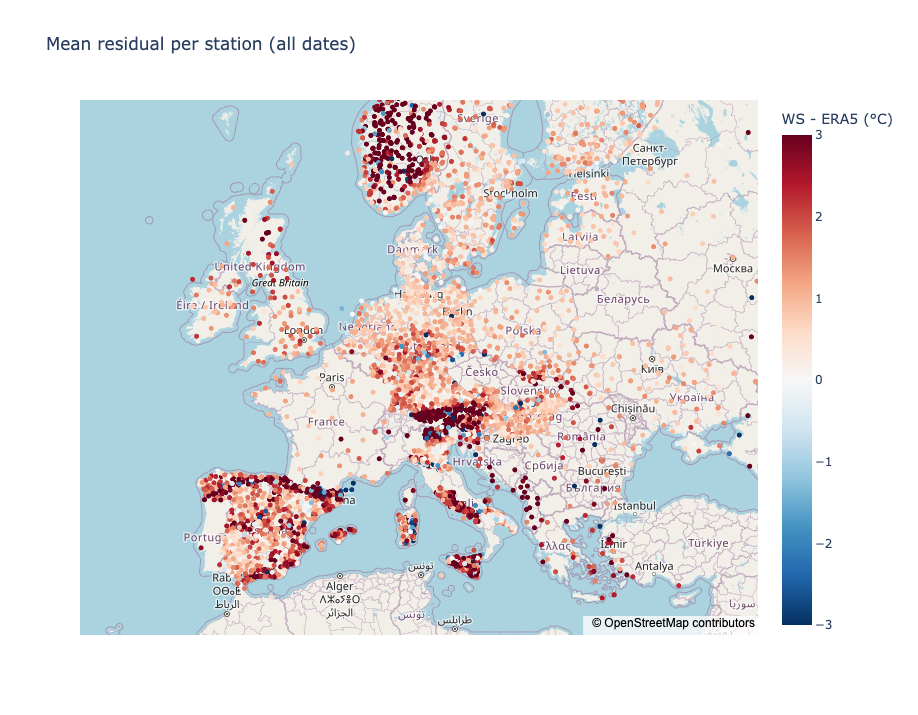

In [8]:
station_mean = residuals_df.group_by("STAID").agg(
    pl.col("residual").mean(), pl.col("lon").first(), pl.col("lat").first()
)

fig = px.scatter_map(
    station_mean,
    lat="lat",
    lon="lon",
    color="residual",
    color_continuous_scale="RdBu_r",
    range_color=[-3, 3],
    zoom=3,
    center={"lat": 50, "lon": 10},
    hover_data=["STAID", "residual"],
    title="Mean residual per station (all dates)",
)
fig.update_traces(marker=dict(size=6))
fig.update_layout(
    height=700,
    width=1000,
    template="plotly_white",
    coloraxis_colorbar_title="WS - ERA5 (°C)",
    map_style="open-street-map",
)
fig.show()

## Partial dependence plots (bootstrap 95% CI)

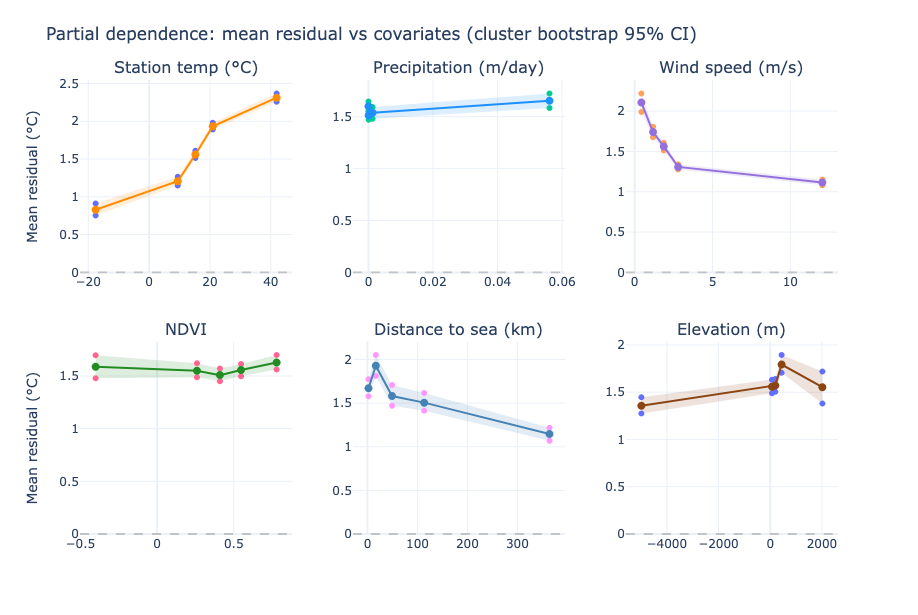

In [40]:
features = {
    "station_celsius": ("Station temp (°C)", "rgb(255,140,0)"),
    "tp": ("Precipitation (m/day)", "rgb(30,144,255)"),
    "wind": ("Wind speed (m/s)", "rgb(147,112,219)"),
    "ndvi": ("NDVI", "rgb(34,139,34)"),
    "dist_to_sea_km": ("Distance to sea (km)", "rgb(70,130,180)"),
    "elevation": ("Elevation (m)", "rgb(139,69,19)"),
}

fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=[v[0] for v in features.values()],
    horizontal_spacing=0.08,
    vertical_spacing=0.15,
)

for i, (col, (label, rgb)) in enumerate(features.items()):
    row, c = divmod(i, 3)
    row += 1
    c += 1
    rgba = rgb.replace("rgb(", "rgba(").replace(")", ",0.15)")

    df, bins = pdp.bin_features(residuals_df, col, n_bins=5)
    means, ci_lo, ci_hi = pdp.pdp_cluster_bootstrap(df, "bin", bins, rng=rng)

    centers = pdp.bin_centers(bins, df[col].min(), df[col].max())

    fig.add_trace(
        go.Scatter(
            x=np.concatenate([centers, centers[::-1]]),
            y=np.concatenate([ci_hi, ci_lo[::-1]]),
            fill="toself",
            fillcolor=rgba,
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        ),
        row=row,
        col=c,
    )

    fig.add_trace(
        go.Scatter(
            x=centers,
            y=means,
            mode="lines+markers",
            marker=dict(size=8, color=rgb),
            line=dict(color=rgb, width=2),
            name=label,
            showlegend=False,
            hovertemplate=f"{label}: %{{x:.2f}}<br>Mean: %{{y:.3f}} °C<extra></extra>",
        ),
        row=row,
        col=c,
    )

    fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4, row=row, col=c)

fig.update_layout(
    height=600,
    width=1200,
    template="plotly_white",
    title="Partial dependence: mean residual vs covariates (cluster bootstrap 95% CI)",
    margin=dict(t=80),
)
fig.update_yaxes(title_text="Mean residual (°C)", col=1)
fig.show()

In [46]:
degurba_order = [
    "Water",
    "Very low density rural",
    "Low density rural",
    "Rural cluster",
    "Suburban",
    "Semi-dense urban cluster",
    "Dense urban cluster",
    "Urban centre",
]
degurba_colors = [
    "rgb(30,144,255)",
    "rgb(144,238,144)",
    "rgb(34,139,34)",
    "rgb(0,100,0)",
    "rgb(255,165,0)",
    "rgb(255,140,0)",
    "rgb(220,20,60)",
    "rgb(139,0,0)",
]

means, ci_lo, ci_hi = pdp.pdp_cluster_bootstrap(
    residuals_df, "degurba_label", degurba_order, rng=rng
)

In [54]:
station_dist = (
    residuals_df.group_by("degurba_label")
    .len()
    .with_columns(pl.col("degurba_label").cast(pl.Enum(degurba_order)))
    .sort("degurba_label")["len"]
    / len(residuals_df)
).to_numpy()

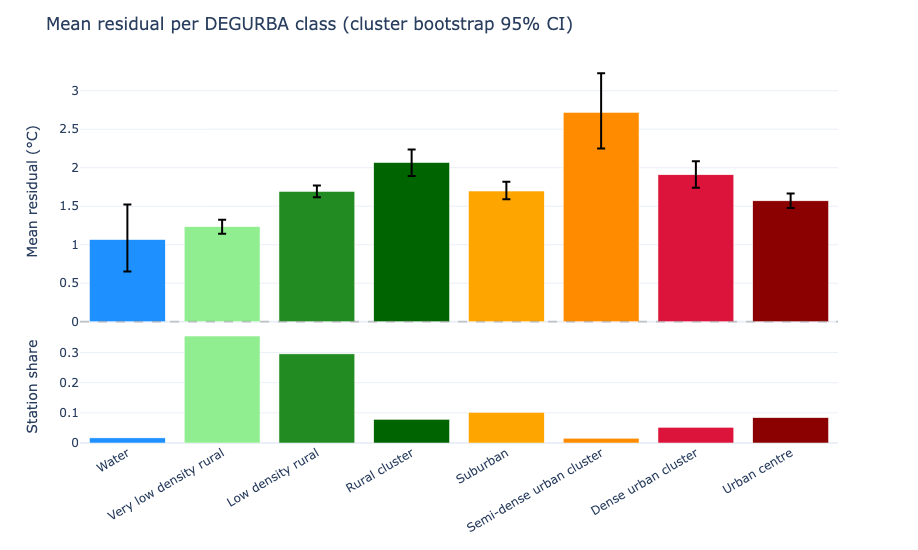

In [59]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.7, 0.3],
    vertical_spacing=0.02,
)

# Top: mean residual bars
fig.add_trace(
    go.Bar(
        x=degurba_order,
        y=means,
        marker_color=degurba_colors[: len(degurba_order)],
        error_y=dict(
            type="data",
            symmetric=False,
            array=ci_hi - means,
            arrayminus=means - ci_lo,
            color="black",
            thickness=2,
            width=4,
        ),
        showlegend=False,
        hovertemplate="%{x}<br>Mean: %{y:.3f} °C<extra></extra>",
    ),
    row=1,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4, row=1, col=1)

# Bottom: normalized station distribution
fig.add_trace(
    go.Bar(
        x=degurba_order,
        y=station_dist,
        marker_color=degurba_colors[: len(degurba_order)],
        showlegend=False,
        hovertemplate="%{x}<br>Share: %{y:.1%}<extra></extra>",
    ),
    row=2,
    col=1,
)

fig.update_layout(
    height=550,
    width=800,
    template="plotly_white",
    title="Mean residual per DEGURBA class (cluster bootstrap 95% CI)",
    margin=dict(t=60),
)
fig.update_yaxes(title_text="Mean residual (°C)", row=1, col=1)
fig.update_yaxes(title_text="Station share", row=2, col=1)
fig.update_xaxes(tickangle=-30, row=2, col=1)

fig.show()

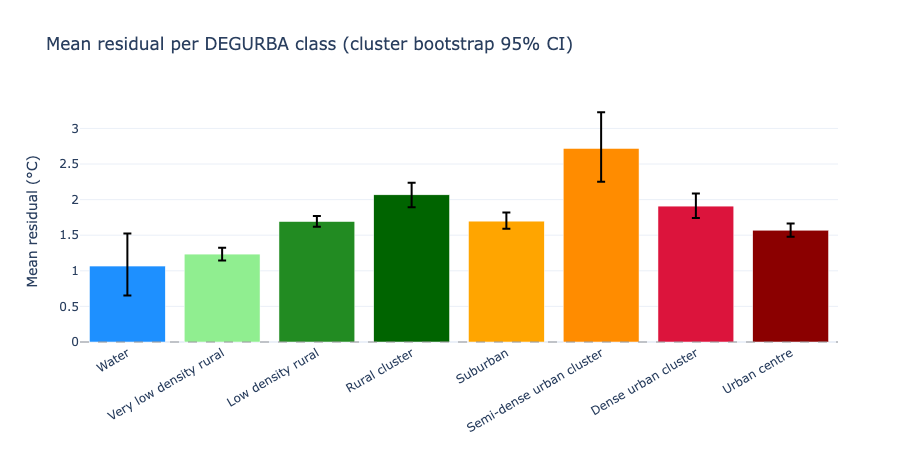

In [49]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=degurba_order,
        y=means,
        marker_color=degurba_colors[: len(degurba_order)],
        error_y=dict(
            type="data",
            symmetric=False,
            array=ci_hi - means,
            arrayminus=means - ci_lo,
            color="black",
            thickness=2,
            width=4,
        ),
        showlegend=False,
        hovertemplate="%{x}<br>Mean: %{y:.3f} °C<extra></extra>",
    ),
)
fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4)
fig.update_layout(
    height=450,
    width=800,
    template="plotly_white",
    title="Mean residual per DEGURBA class (cluster bootstrap 95% CI)",
    yaxis_title="Mean residual (°C)",
    xaxis_tickangle=-30,
)
fig.show()

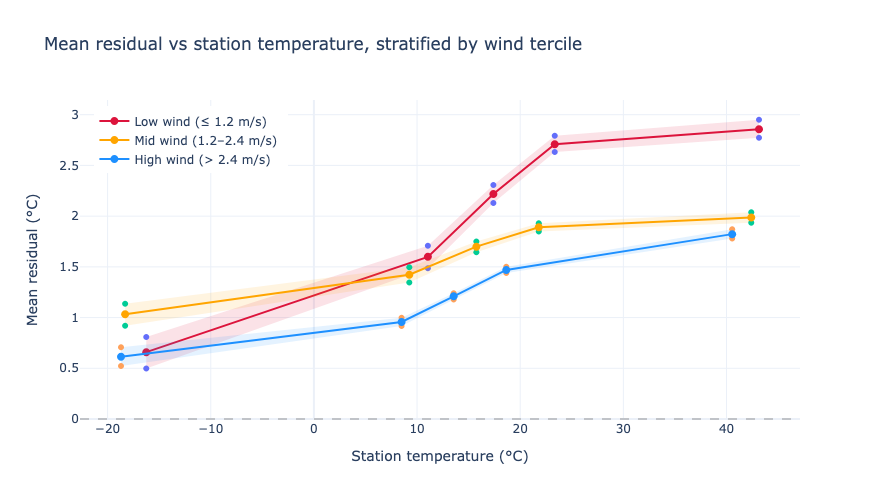

In [24]:
wind_terciles = residuals_df["wind"].quantile([1 / 3, 2 / 3]).values
low_wind = residuals_df[residuals_df["wind"] <= wind_terciles[0]]
mid_wind = residuals_df[
    (residuals_df["wind"] > wind_terciles[0])
    & (residuals_df["wind"] <= wind_terciles[1])
]
high_wind = residuals_df[residuals_df["wind"] > wind_terciles[1]]

centers_lo, mean_lo, ci_lo_lo, ci_hi_lo = pdp_cluster_bootstrap(
    low_wind, "station_celsius"
)
centers_mid, mean_mid, ci_lo_mid, ci_hi_mid = pdp_cluster_bootstrap(
    mid_wind, "station_celsius"
)
centers_hi, mean_hi, ci_lo_hi, ci_hi_hi = pdp_cluster_bootstrap(
    high_wind, "station_celsius"
)

strat_records = []
for centers, mean, ci_lo, ci_hi, label in [
    (
        centers_lo,
        mean_lo,
        ci_lo_lo,
        ci_hi_lo,
        f"Low wind (≤ {wind_terciles[0]:.1f} m/s)",
    ),
    (
        centers_mid,
        mean_mid,
        ci_lo_mid,
        ci_hi_mid,
        f"Mid wind ({wind_terciles[0]:.1f}–{wind_terciles[1]:.1f} m/s)",
    ),
    (
        centers_hi,
        mean_hi,
        ci_lo_hi,
        ci_hi_hi,
        f"High wind (> {wind_terciles[1]:.1f} m/s)",
    ),
]:
    for j in range(len(centers)):
        strat_records.append(
            {
                "group": label,
                "center": centers[j],
                "mean": mean[j],
                "ci_lo": ci_lo[j],
                "ci_hi": ci_hi[j],
            }
        )

fig = go.Figure()

for centers, mean, ci_lo, ci_hi, color, label in [
    (
        centers_lo,
        mean_lo,
        ci_lo_lo,
        ci_hi_lo,
        "rgb(220,20,60)",
        f"Low wind (≤ {wind_terciles[0]:.1f} m/s)",
    ),
    (
        centers_mid,
        mean_mid,
        ci_lo_mid,
        ci_hi_mid,
        "rgb(255,165,0)",
        f"Mid wind ({wind_terciles[0]:.1f}–{wind_terciles[1]:.1f} m/s)",
    ),
    (
        centers_hi,
        mean_hi,
        ci_lo_hi,
        ci_hi_hi,
        "rgb(30,144,255)",
        f"High wind (> {wind_terciles[1]:.1f} m/s)",
    ),
]:
    rgba = color.replace("rgb(", "rgba(").replace(")", ",0.12)")
    fig.add_trace(
        go.Scatter(
            x=np.concatenate([centers, centers[::-1]]),
            y=np.concatenate([ci_hi, ci_lo[::-1]]),
            fill="toself",
            fillcolor=rgba,
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=centers,
            y=mean,
            mode="lines+markers",
            marker=dict(size=8, color=color),
            line=dict(color=color, width=2),
            name=label,
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4)
fig.update_layout(
    height=500,
    width=800,
    template="plotly_white",
    title="Mean residual vs station temperature, stratified by wind tercile",
    xaxis_title="Station temperature (°C)",
    yaxis_title="Mean residual (°C)",
    legend=dict(x=0.02, y=0.98),
)
fig.show()
fig.write_html(FIGS / "temp_pdp_cond_wind.html", include_plotlyjs="cdn")
pd.DataFrame(strat_records).to_parquet(
    PLOT_DATA / "temp_pdp_cond_wind.parquet", index=False
)

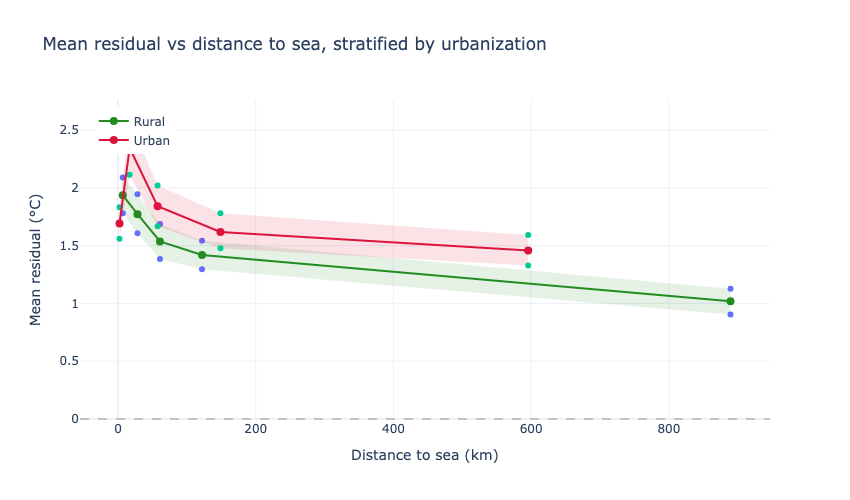

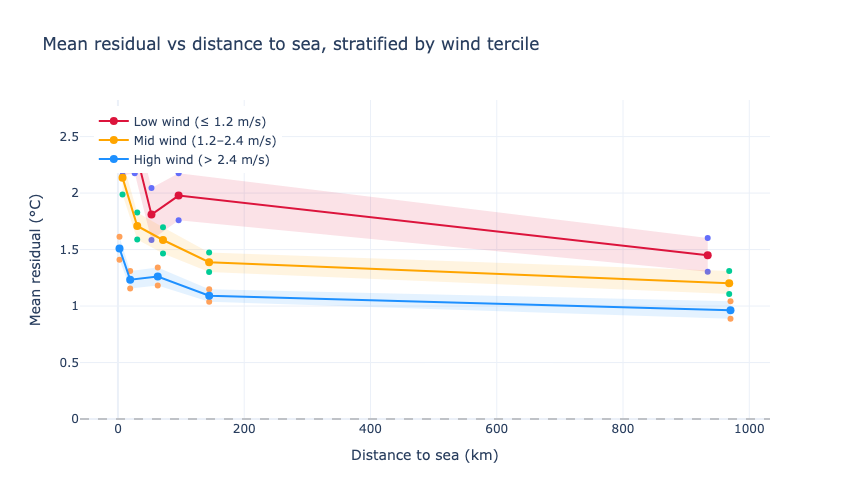

In [17]:
# 1. Distance to sea stratified by DEGURBA (rural vs urban)
rural_labels = ["Very low density rural", "Low density rural", "Rural cluster"]
urban_labels = [
    "Suburban",
    "Semi-dense urban cluster",
    "Dense urban cluster",
    "Urban centre",
]

rural = residuals_df[residuals_df["degurba_label"].isin(rural_labels)]
urban = residuals_df[residuals_df["degurba_label"].isin(urban_labels)]

centers_r, mean_r, ci_lo_r, ci_hi_r = pdp_cluster_bootstrap(rural, "dist_to_sea_km")
centers_u, mean_u, ci_lo_u, ci_hi_u = pdp_cluster_bootstrap(urban, "dist_to_sea_km")

fig = go.Figure()

for centers, mean, ci_lo, ci_hi, color, label in [
    (centers_r, mean_r, ci_lo_r, ci_hi_r, "rgb(34,139,34)", "Rural"),
    (centers_u, mean_u, ci_lo_u, ci_hi_u, "rgb(220,20,60)", "Urban"),
]:
    rgba = color.replace("rgb(", "rgba(").replace(")", ",0.12)")
    fig.add_trace(
        go.Scatter(
            x=np.concatenate([centers, centers[::-1]]),
            y=np.concatenate([ci_hi, ci_lo[::-1]]),
            fill="toself",
            fillcolor=rgba,
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=centers,
            y=mean,
            mode="lines+markers",
            marker=dict(size=8, color=color),
            line=dict(color=color, width=2),
            name=label,
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4)
fig.update_layout(
    height=500,
    width=800,
    template="plotly_white",
    title="Mean residual vs distance to sea, stratified by urbanization",
    xaxis_title="Distance to sea (km)",
    yaxis_title="Mean residual (°C)",
    legend=dict(x=0.02, y=0.98),
)
fig.show()

# 2. Distance to sea stratified by wind tercile
wind_terciles = residuals_df["wind"].quantile([1 / 3, 2 / 3]).values
low_wind = residuals_df[residuals_df["wind"] <= wind_terciles[0]]
mid_wind = residuals_df[
    (residuals_df["wind"] > wind_terciles[0])
    & (residuals_df["wind"] <= wind_terciles[1])
]
high_wind = residuals_df[residuals_df["wind"] > wind_terciles[1]]

centers_lo, mean_lo, ci_lo_lo, ci_hi_lo = pdp_cluster_bootstrap(
    low_wind, "dist_to_sea_km"
)
centers_mid, mean_mid, ci_lo_mid, ci_hi_mid = pdp_cluster_bootstrap(
    mid_wind, "dist_to_sea_km"
)
centers_hi, mean_hi, ci_lo_hi, ci_hi_hi = pdp_cluster_bootstrap(
    high_wind, "dist_to_sea_km"
)

fig = go.Figure()

for centers, mean, ci_lo, ci_hi, color, label in [
    (
        centers_lo,
        mean_lo,
        ci_lo_lo,
        ci_hi_lo,
        "rgb(220,20,60)",
        f"Low wind (≤ {wind_terciles[0]:.1f} m/s)",
    ),
    (
        centers_mid,
        mean_mid,
        ci_lo_mid,
        ci_hi_mid,
        "rgb(255,165,0)",
        f"Mid wind ({wind_terciles[0]:.1f}–{wind_terciles[1]:.1f} m/s)",
    ),
    (
        centers_hi,
        mean_hi,
        ci_lo_hi,
        ci_hi_hi,
        "rgb(30,144,255)",
        f"High wind (> {wind_terciles[1]:.1f} m/s)",
    ),
]:
    rgba = color.replace("rgb(", "rgba(").replace(")", ",0.12)")
    fig.add_trace(
        go.Scatter(
            x=np.concatenate([centers, centers[::-1]]),
            y=np.concatenate([ci_hi, ci_lo[::-1]]),
            fill="toself",
            fillcolor=rgba,
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=centers,
            y=mean,
            mode="lines+markers",
            marker=dict(size=8, color=color),
            line=dict(color=color, width=2),
            name=label,
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color="grey", opacity=0.4)
fig.update_layout(
    height=500,
    width=800,
    template="plotly_white",
    title="Mean residual vs distance to sea, stratified by wind tercile",
    xaxis_title="Distance to sea (km)",
    yaxis_title="Mean residual (°C)",
    legend=dict(x=0.02, y=0.98),
)
fig.show()

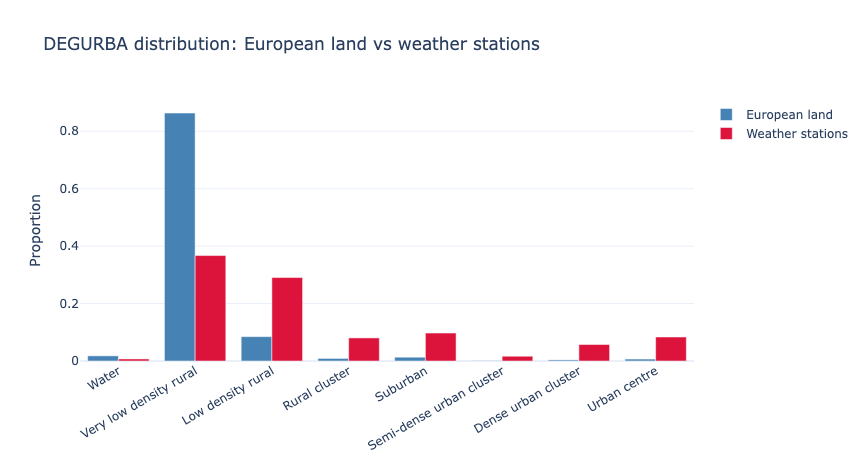

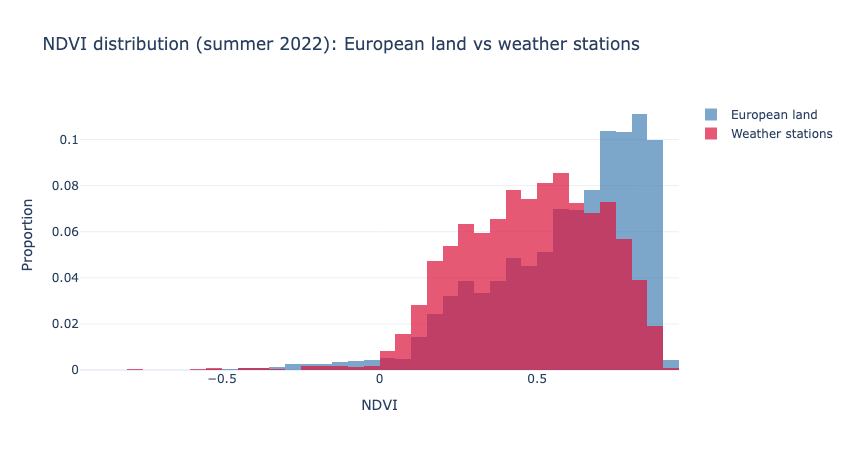

In [ ]:
# Sample DEGURBA and NDVI across all European land pixels, compare to station distributions
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import transform_bounds

# Load Europe boundary for masking
gadm = gpd.read_file(DATA / "gadm_410_europe.gpkg")
europe = gadm.dissolve()

# --- DEGURBA: station vs all European land ---
degurba_path = (
    OUT
    / "GHS_SMOD_E2020_GLOBE_R2023A_54009_1000_V2_0/GHS_SMOD_E2020_GLOBE_R2023A_54009_1000_V2_0.tif"
)

with rasterio.open(degurba_path) as src:
    europe_reproj = europe.to_crs(src.crs)
    masked, _ = rio_mask(src, europe_reproj.geometry, crop=True, nodata=src.nodata)
    degurba_all = masked[0]
    degurba_all = degurba_all[degurba_all != src.nodata]
    degurba_all = degurba_all[degurba_all > 0]  # drop zeros if any

DEGURBA_LABELS = {
    10: "Water",
    11: "Very low density rural",
    12: "Low density rural",
    13: "Rural cluster",
    21: "Suburban",
    22: "Semi-dense urban cluster",
    23: "Dense urban cluster",
    30: "Urban centre",
}
degurba_order = list(DEGURBA_LABELS.values())

# Reference distribution (all European land pixels)
ref_degurba = (
    pd.Series(degurba_all)
    .map(DEGURBA_LABELS)
    .value_counts(normalize=True)
    .reindex(degurba_order)
    .fillna(0)
)

# Station distribution
sta_degurba = (
    residuals_df.drop_duplicates("STAID")["degurba_label"]
    .value_counts(normalize=True)
    .reindex(degurba_order)
    .fillna(0)
)

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=degurba_order,
        y=ref_degurba.values,
        name="European land",
        marker_color="rgb(70,130,180)",
    )
)
fig.add_trace(
    go.Bar(
        x=degurba_order,
        y=sta_degurba.values,
        name="Weather stations",
        marker_color="rgb(220,20,60)",
    )
)
fig.update_layout(
    barmode="group",
    height=450,
    width=900,
    template="plotly_white",
    title="DEGURBA distribution: European land vs weather stations",
    yaxis_title="Proportion",
    xaxis_tickangle=-30,
)
fig.show()

# --- NDVI: station vs all European land (use one quarter as representative) ---
ndvi_dir = DATA / "sentinel2_ndvi/"
# Pick a summer quarter for representative vegetation
ndvi_path = ndvi_dir / "ndvi_2022-06-01_2022-09-01.tif"

with rasterio.open(ndvi_path) as src:
    europe_reproj = europe.to_crs(src.crs)
    masked, _ = rio_mask(src, europe_reproj.geometry, crop=True, nodata=src.nodata)
    ndvi_all = masked[0].astype(float)
    ndvi_all = ndvi_all[ndvi_all != src.nodata]
    ndvi_all = ndvi_all / 254 * 2 - 1  # same rescaling as in pipeline

# Subsample reference (millions of pixels)
rng = np.random.default_rng(42)
ndvi_ref_sample = rng.choice(ndvi_all, size=100_000, replace=False)

# Station NDVI for same quarter
sta_ndvi = (
    residuals_df.loc[
        (residuals_df["date"] >= "2022-06-01") & (residuals_df["date"] < "2022-09-01"),
        "ndvi",
    ]
    .dropna()
    .values
)

fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=ndvi_ref_sample,
        nbinsx=50,
        name="European land",
        marker_color="rgb(70,130,180)",
        opacity=0.7,
        histnorm="probability",
    )
)
fig.add_trace(
    go.Histogram(
        x=sta_ndvi,
        nbinsx=50,
        name="Weather stations",
        marker_color="rgb(220,20,60)",
        opacity=0.7,
        histnorm="probability",
    )
)
fig.update_layout(
    barmode="overlay",
    height=450,
    width=800,
    template="plotly_white",
    title="NDVI distribution (summer 2022): European land vs weather stations",
    xaxis_title="NDVI",
    yaxis_title="Proportion",
)
fig.show()

# --- Distance to sea: station vs uniform European land sample ---
from shapely.geometry import Point

# Sample random points on European land
europe_3035 = europe.to_crs("EPSG:3035")
bounds = europe_3035.total_bounds  # minx, miny, maxx, maxy
coastline = europe_3035.boundary.iloc[0]

rng = np.random.default_rng(42)
n_samples = 20_000
random_points = []
while len(random_points) < n_samples:
    xs = rng.uniform(bounds[0], bounds[2], size=n_samples * 2)
    ys = rng.uniform(bounds[1], bounds[3], size=n_samples * 2)
    pts = gpd.GeoSeries([Point(x, y) for x, y in zip(xs, ys)], crs="EPSG:3035")
    inside = pts[pts.within(europe_3035.geometry.iloc[0])]
    random_points.extend(inside.tolist())
random_points = random_points[:n_samples]

ref_dist_sea = gpd.GeoSeries(random_points, crs="EPSG:3035").distance(coastline) / 1000

# Station distances
sta_dist_sea = residuals_df.drop_duplicates("STAID")["dist_to_sea_km"].dropna()

fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=ref_dist_sea,
        nbinsx=50,
        name="European land (uniform)",
        marker_color="rgb(70,130,180)",
        opacity=0.7,
        histnorm="probability",
    )
)
fig.add_trace(
    go.Histogram(
        x=sta_dist_sea,
        nbinsx=50,
        name="Weather stations",
        marker_color="rgb(220,20,60)",
        opacity=0.7,
        histnorm="probability",
    )
)
fig.update_layout(
    barmode="overlay",
    height=450,
    width=800,
    template="plotly_white",
    title="Distance to sea distribution: uniform European land vs weather stations",
    xaxis_title="Distance to sea (km)",
    yaxis_title="Proportion",
)
fig.show()